## 1. EDA Objectives
- Understand the structure of the dataset.
- Check data completeness and duplicates.
- Explore numerical and categorical variables.
- Analyze revenue, cost, profit and profit margin.
- Compare services, industries, regions and client types.
- Analyze project status, lead sources and acquisition channels.
- Study project duration, team size, ratings and marketing spend.
- Identify relationships between numerical variables.
- Extract business insights from the data.

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 3. Load the Cleaned Dataset

In [2]:
file_path = "ANALYSIS INTERSNSHIP PROJECT.xlsx"
df = pd.read_excel(file_path, sheet_name="Cleaned_Data")
df.head()

,Project_ID,Client_ID,Client_Name,Project_Date,Service,Service_Category,Industry,Region,Client_Type,Project_Status,Team_Size,Project_Duration_Days,Quoted_Value,Discount,Revenue,Project_Cost,Profit,Profit_Margin_Pct,Lead_Source,Marketing_Spend,Customer_Rating,Acquisition_Channel
0,JSM10088,C0264,Client 0264,2025-01-02,Online Reputation Management,Online Reputation Management,Real Estate,Chennai,New,Completed,10,68.00,71400,0,71400,38500,32900,46.08,Email Campaign,11500,4.00,Referral
1,JSM10700,C0014,Client 0014,2025-01-03,Web Development,Web Development,Education,Hyderabad,Returning,Completed,4,41.00,88400,17700,70700,52300,18400,26.03,Direct,11900,4.40,Paid Search
2,JSM10034,C0023,Client 0023,2025-01-04,Content Marketing,Content Marketing,Hospitality,Bengaluru,Returning,Ongoing,7,52.00,83900,4200,79700,57000,22700,28.48,Partner,10500,3.60,Referral
3,JSM10392,C0347,Client 0347,2025-01-05,SEO,SEO,Hospitality,Bengaluru,New,Completed,5,NaN,141500,0,141500,92100,49400,34.91,Google,5800,4.60,Referral
4,JSM10418,C0256,Client 0256,2025-01-05,Web Design,Web Design,B2B Services,Bengaluru,New,Ongoing,10,71.00,61400,3100,58300,47400,10900,18.70,Partner,2500,5.00,Direct


## 4. Dataset Overview

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

Rows: 1501
Columns: 22

Columns:
['Project_ID', 'Client_ID', 'Client_Name', 'Project_Date', 'Service', 'Service_Category', 'Industry', 'Region', 'Client_Type', 'Project_Status', 'Team_Size', 'Project_Duration_Days', 'Quoted_Value', 'Discount', 'Revenue', 'Project_Cost', 'Profit', 'Profit_Margin_Pct', 'Lead_Source', 'Marketing_Spend', 'Customer_Rating', 'Acquisition_Channel']

Data types:


,Data Type
Project_ID,object
Client_ID,object
Client_Name,object
Project_Date,datetime64[ns]
Service,object
Service_Category,object
Industry,object
Region,object
Client_Type,object
Project_Status,object


In [4]:
df.info()
display(df.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1501 entries, 0 to 1500
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Project_ID             1501 non-null   object        
 1   Client_ID              1501 non-null   object        
 2   Client_Name            1501 non-null   object        
 3   Project_Date           1501 non-null   datetime64[ns]
 4   Service                1501 non-null   object        
 5   Service_Category       1501 non-null   object        
 6   Industry               1501 non-null   object        
 7   Region                 1501 non-null   object        
 8   Client_Type            1501 non-null   object        
 9   Project_Status         1501 non-null   object        
 10  Team_Size              1501 non-null   int64         
 11  Project_Duration_Days  1483 non-null   float64       
 12  Quoted_Value           1501 non-null   int64         
 13  Dis

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Project_ID,1501,1500,JSM11280,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Client_ID,1501,405,C0050,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Client_Name,1501,405,Client 0050,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Project_Date,1501,NaN,NaN,NaN,2026-01-05 13:34:29.820120064,2025-01-02 00:00:00,2025-06-29 00:00:00,2026-01-06 00:00:00,2026-07-14 00:00:00,2026-12-31 00:00:00,NaN
Service,1501,8,Mobile App Development,209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Service_Category,1501,8,Mobile App Development,209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Industry,1501,9,Education,207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,1501,9,Bengaluru,212,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Client_Type,1501,2,New,929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Project_Status,1501,4,Completed,939,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Data Quality Checks

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": (missing / len(df) * 100).round(2)
})
print("Missing-value summary:")
display(missing_df)

print("Duplicate rows:", df.duplicated().sum())

print("Unique values per column:")
display(df.nunique().sort_values().to_frame("Unique Values"))

Missing-value summary:


,Missing Values,Missing %
Customer_Rating,21,1.40
Project_Duration_Days,18,1.20
Client_Name,0,0.00
Project_Date,0,0.00
Project_ID,0,0.00
Client_ID,0,0.00
Service_Category,0,0.00
Service,0,0.00
Client_Type,0,0.00
Industry,0,0.00


Duplicate rows: 1
Unique values per column:


,Unique Values
Client_Type,2
Project_Status,4
Acquisition_Channel,5
Lead_Source,7
Service_Category,8
Service,8
Region,9
Team_Size,9
Industry,9
Customer_Rating,30


## 6. Date Preparation

In [6]:
df["Project_Date"] = pd.to_datetime(df["Project_Date"], errors="coerce")
df["Year"] = df["Project_Date"].dt.year
df["Month"] = df["Project_Date"].dt.month
df["Month_Name"] = df["Project_Date"].dt.strftime("%b")
df["Year_Month"] = df["Project_Date"].dt.to_period("M").astype(str)

display(df[["Project_Date", "Year", "Month", "Month_Name", "Year_Month"]].head())

,Project_Date,Year,Month,Month_Name,Year_Month
0,2025-01-02,2025,1,Jan,2025-01
1,2025-01-03,2025,1,Jan,2025-01
2,2025-01-04,2025,1,Jan,2025-01
3,2025-01-05,2025,1,Jan,2025-01
4,2025-01-05,2025,1,Jan,2025-01


## 7. Key Business Metrics

In [7]:
total_revenue = df["Revenue"].sum()
total_cost = df["Project_Cost"].sum()
total_profit = df["Profit"].sum()
avg_margin = df["Profit_Margin_Pct"].mean()
avg_rating = df["Customer_Rating"].mean()

kpis = pd.DataFrame({
    "Metric": ["Total Projects", "Total Revenue", "Total Project Cost",
               "Total Profit", "Average Profit Margin (%)",
               "Average Customer Rating"],
    "Value": [len(df), total_revenue, total_cost, total_profit,
              avg_margin, avg_rating]
})
display(kpis)

,Metric,Value
0,Total Projects,"1,501.00"
1,Total Revenue,"69,877,300.00"
2,Total Project Cost,"47,143,000.00"
3,Total Profit,"22,734,300.00"
4,Average Profit Margin (%),31.84
5,Average Customer Rating,4.06


## 8. Categorical Variable Analysis

In [8]:
categorical_columns = [
    "Service", "Service_Category", "Industry", "Region",
    "Client_Type", "Project_Status", "Lead_Source",
    "Acquisition_Channel"
]

for col in categorical_columns:
    print(f"--- {col} ---")
    display(df[col].value_counts().to_frame("Count"))

--- Service ---


,Count
Service,
Mobile App Development,209
Web Development,202
Social Media Marketing,188
PPC,188
Content Marketing,186
Online Reputation Management,184
Web Design,174
SEO,170


--- Service_Category ---


,Count
Service_Category,
Mobile App Development,209
Web Development,202
Social Media Marketing,188
PPC,188
Content Marketing,186
Online Reputation Management,184
Web Design,174
SEO,170


--- Industry ---


...

,Count
Project_Status,
Completed,939
Ongoing,321
Delayed,166
Cancelled,75


--- Lead_Source ---


,Count
Lead_Source,
Direct,268
Partner,262
Social Media,248
Email Campaign,246
Referral,233
Google,232
Unknown,12


--- Acquisition_Channel ---


,Count
Acquisition_Channel,
Direct,308
Referral,307
Social,307
Paid Search,300
Organic Search,279


## 9. Project Status Distribution

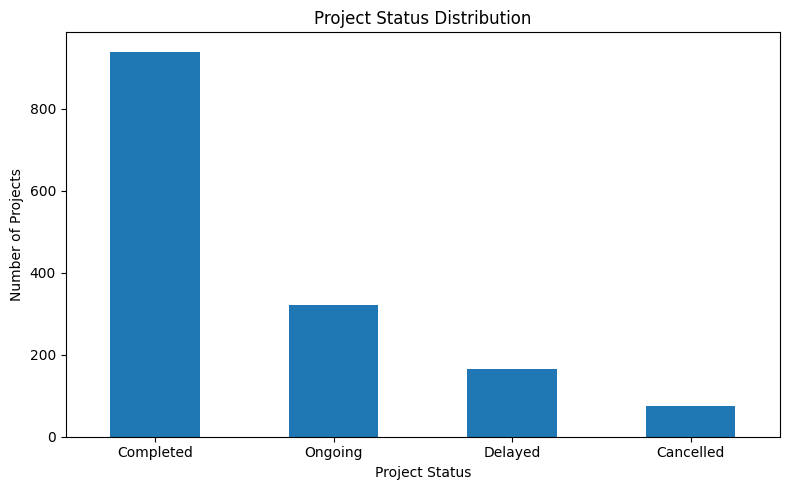

In [9]:
status_counts = df["Project_Status"].value_counts()

plt.figure(figsize=(8,5))
status_counts.plot(kind="bar")
plt.title("Project Status Distribution")
plt.xlabel("Project Status")
plt.ylabel("Number of Projects")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Service-wise Analysis

In [10]:
service_summary = (
    df.groupby("Service")
      .agg(Projects=("Project_ID","count"),
           Revenue=("Revenue","sum"),
           Cost=("Project_Cost","sum"),
           Profit=("Profit","sum"),
           Avg_Margin=("Profit_Margin_Pct","mean"))
      .sort_values("Revenue", ascending=False)
)
display(service_summary)

,Projects,Revenue,Cost,Profit,Avg_Margin
Service,,,,,
Mobile App Development,209,9331700,6399700,2932000,30.22
Web Development,202,9287200,6253700,3033500,32.25
PPC,188,8826000,5995800,2830200,31.17
Social Media Marketing,188,8645500,5910100,2735400,31.68
Online Reputation Management,184,8592300,5682200,2910100,33.07
Web Design,174,8576500,5677800,2898700,32.97
SEO,170,8439000,5684400,2754600,32.06
Content Marketing,186,8179100,5539300,2639800,31.60


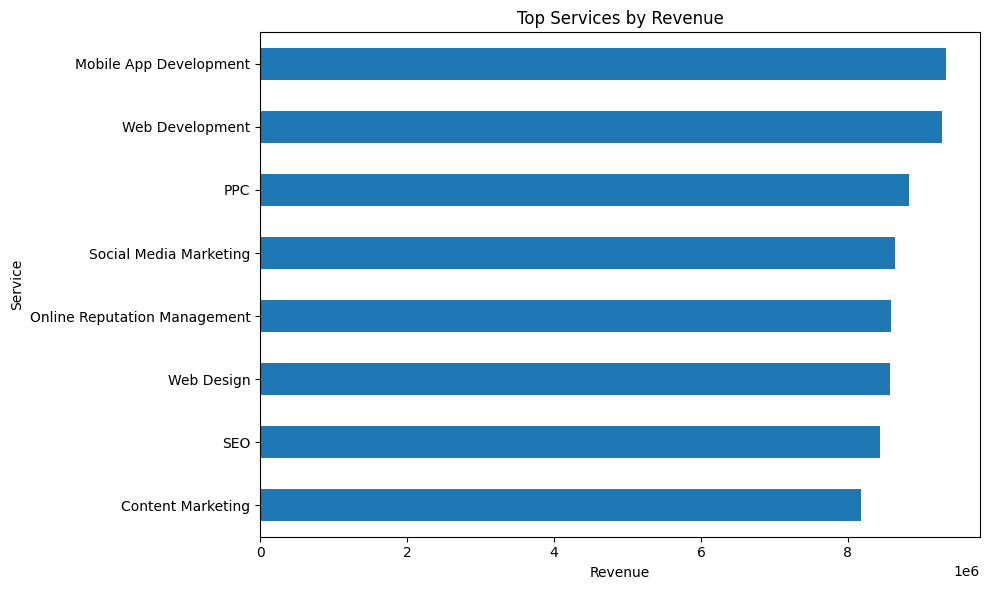

In [11]:
plt.figure(figsize=(10,6))
service_summary.head(10)["Revenue"].sort_values().plot(kind="barh")
plt.title("Top Services by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Service")
plt.tight_layout()
plt.show()

## 11. Industry-wise Analysis

In [12]:
industry_summary = (
    df.groupby("Industry")
      .agg(Projects=("Project_ID","count"),
           Revenue=("Revenue","sum"),
           Profit=("Profit","sum"),
           Avg_Rating=("Customer_Rating","mean"))
      .sort_values("Revenue", ascending=False)
)
display(industry_summary)

,Projects,Revenue,Profit,Avg_Rating
Industry,,,,
Education,207,9619900,3193600,4.13
E-commerce,188,8888000,2860800,4.12
Hospitality,185,8874900,2928200,4.00
Manufacturing,184,8873700,2761500,4.09
Real Estate,187,8595900,2668300,4.05
Healthcare,178,8340300,2808300,4.11
B2B Services,185,8307600,2656900,4.05
Finance,179,8035500,2767200,3.95
Unknown,8,341500,89500,3.86


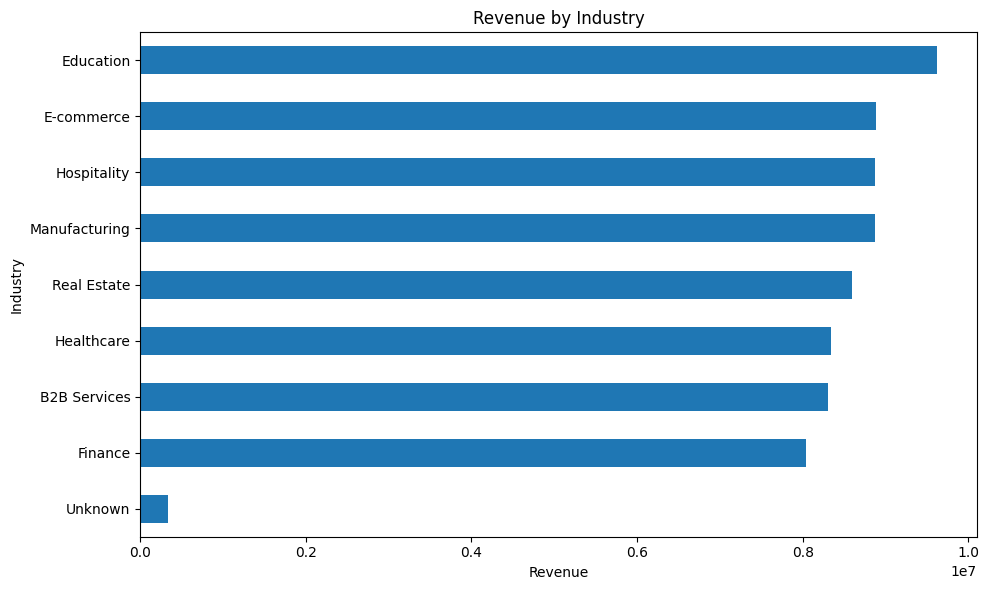

In [13]:
plt.figure(figsize=(10,6))
industry_summary["Revenue"].sort_values().plot(kind="barh")
plt.title("Revenue by Industry")
plt.xlabel("Revenue")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

## 12. Region-wise Analysis

In [14]:
region_summary = (
    df.groupby("Region")
      .agg(Projects=("Project_ID","count"),
           Revenue=("Revenue","sum"),
           Profit=("Profit","sum"),
           Avg_Margin=("Profit_Margin_Pct","mean"))
      .sort_values("Revenue", ascending=False)
)
display(region_summary)

,Projects,Revenue,Profit,Avg_Margin
Region,,,,
Bengaluru,212,10792000,3605300,32.61
Hyderabad,180,8958900,2991200,32.48
Pune,180,8568000,2745200,31.33
Chennai,186,8515900,2889000,33.12
Kolkata,183,8336200,2701300,32.33
Delhi Ncr,194,8293700,2646400,31.06
Ahmedabad,190,8194700,2474200,29.77
Mumbai,158,7313200,2329000,31.63
Unknown,18,904700,352700,35.64


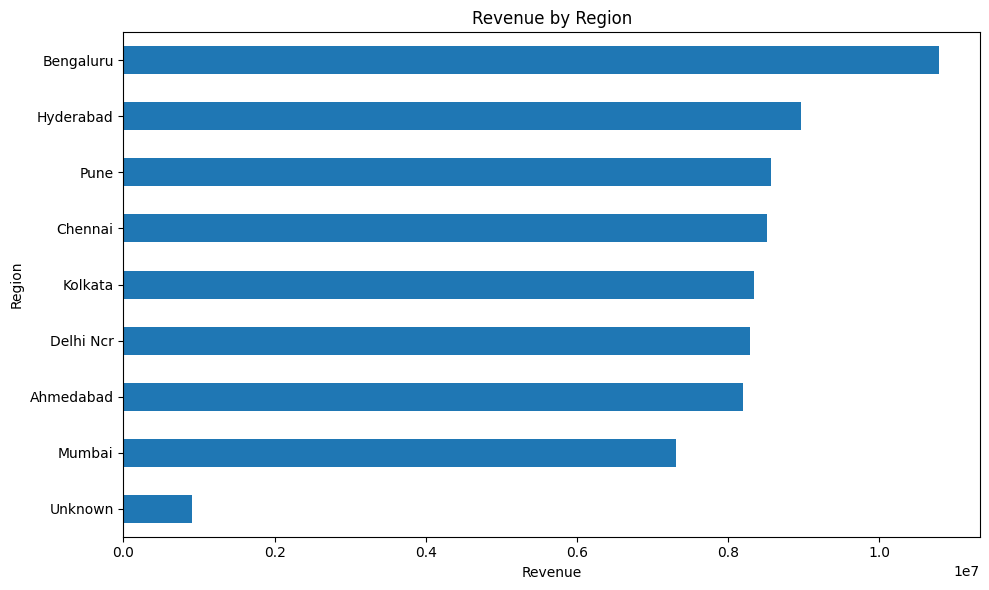

In [15]:
plt.figure(figsize=(10,6))
region_summary["Revenue"].sort_values().plot(kind="barh")
plt.title("Revenue by Region")
plt.xlabel("Revenue")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

## 13. Client Type Analysis

,Projects,Revenue,Profit,Avg_Rating
Client_Type,,,,
New,929,43076600,13795100,4.07
Returning,572,26800700,8939200,4.05


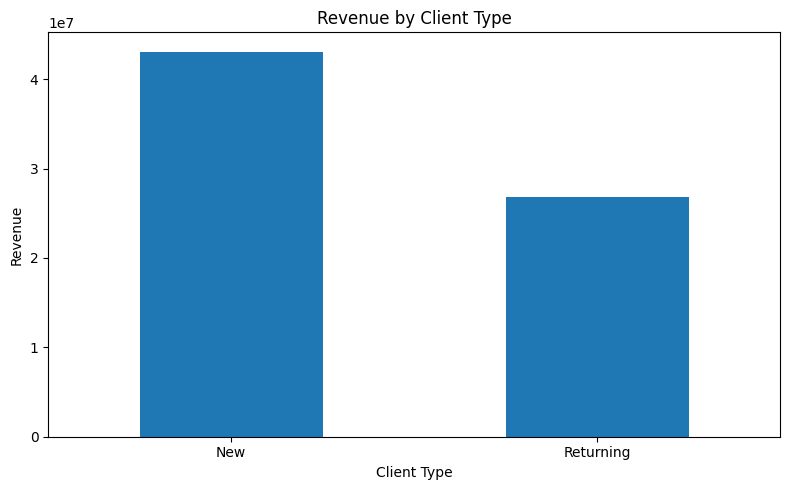

In [16]:
client_summary = (
    df.groupby("Client_Type")
      .agg(Projects=("Project_ID","count"),
           Revenue=("Revenue","sum"),
           Profit=("Profit","sum"),
           Avg_Rating=("Customer_Rating","mean"))
      .sort_values("Revenue", ascending=False)
)
display(client_summary)

plt.figure(figsize=(8,5))
client_summary["Revenue"].plot(kind="bar")
plt.title("Revenue by Client Type")
plt.xlabel("Client Type")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 14. Lead Source and Acquisition Channel

In [17]:
lead_summary = (
    df.groupby("Lead_Source")
      .agg(Projects=("Project_ID","count"),
           Revenue=("Revenue","sum"),
           Profit=("Profit","sum"),
           Avg_Rating=("Customer_Rating","mean"))
      .sort_values("Revenue", ascending=False)
)

channel_summary = (
    df.groupby("Acquisition_Channel")
      .agg(Projects=("Project_ID","count"),
           Revenue=("Revenue","sum"),
           Profit=("Profit","sum"))
      .sort_values("Revenue", ascending=False)
)

print("Lead Source Summary")
display(lead_summary)

print("Acquisition Channel Summary")
display(channel_summary)

Lead Source Summary


,Projects,Revenue,Profit,Avg_Rating
Lead_Source,,,,
Direct,268,13274500,4361600,4.05
Partner,262,11973600,3837800,4.05
Social Media,248,11726200,3951200,4.03
Google,232,11135800,3613100,3.99
Email Campaign,246,10926800,3566100,4.15
Referral,233,10488100,3312400,4.09
Unknown,12,352300,92100,4.41


Acquisition Channel Summary


,Projects,Revenue,Profit
Acquisition_Channel,,,
Direct,308,14481100,4723800
Social,307,14405600,4781900
Paid Search,300,14052600,4476100
Referral,307,13601400,4396600
Organic Search,279,13336600,4355900


## 15. Financial Analysis

In [18]:
financial_summary = df[
    ["Quoted_Value","Revenue","Project_Cost","Profit","Marketing_Spend","Discount"]
].describe().T
display(financial_summary)

,count,mean,std,min,25%,50%,75%,max
Quoted_Value,"1,501.00","50,758.09","28,912.00","15,000.00","30,100.00","43,900.00","65,300.00","239,000.00"
Revenue,"1,501.00","46,553.83","26,888.46","12,000.00","27,100.00","39,700.00","60,000.00","203,200.00"
Project_Cost,"1,501.00","31,407.73","18,936.72","6,300.00","18,000.00","26,800.00","39,500.00","164,700.00"
Profit,"1,501.00","15,146.10","11,816.96",-800.00,"7,000.00","11,700.00","19,900.00","82,700.00"
Marketing_Spend,"1,501.00","5,103.46","3,631.70","1,000.00","2,500.00","4,200.00","6,700.00","25,400.00"
Discount,"1,501.00","4,204.26","4,960.14",0.00,0.00,"3,000.00","6,300.00","35,800.00"


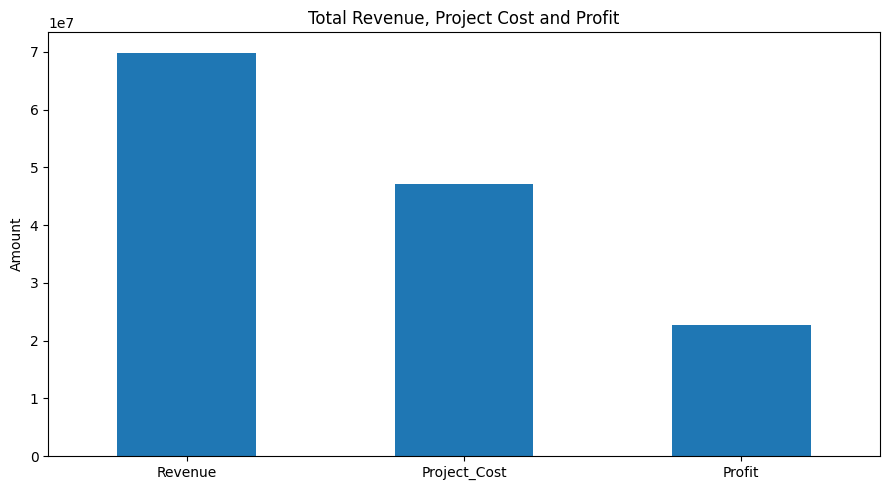

In [19]:
plt.figure(figsize=(9,5))
df[["Revenue","Project_Cost","Profit"]].sum().plot(kind="bar")
plt.title("Total Revenue, Project Cost and Profit")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 16. Monthly Revenue and Profit Trend

,Revenue,Profit
Year_Month,,
2025-01,2823200,901400
2025-02,2622300,847800
2025-03,2921200,957800
2025-04,3502500,1139800
2025-05,3582200,1056200
2025-06,2628000,851300
2025-07,2943200,944600
2025-08,2273800,760600
2025-09,2213300,698200


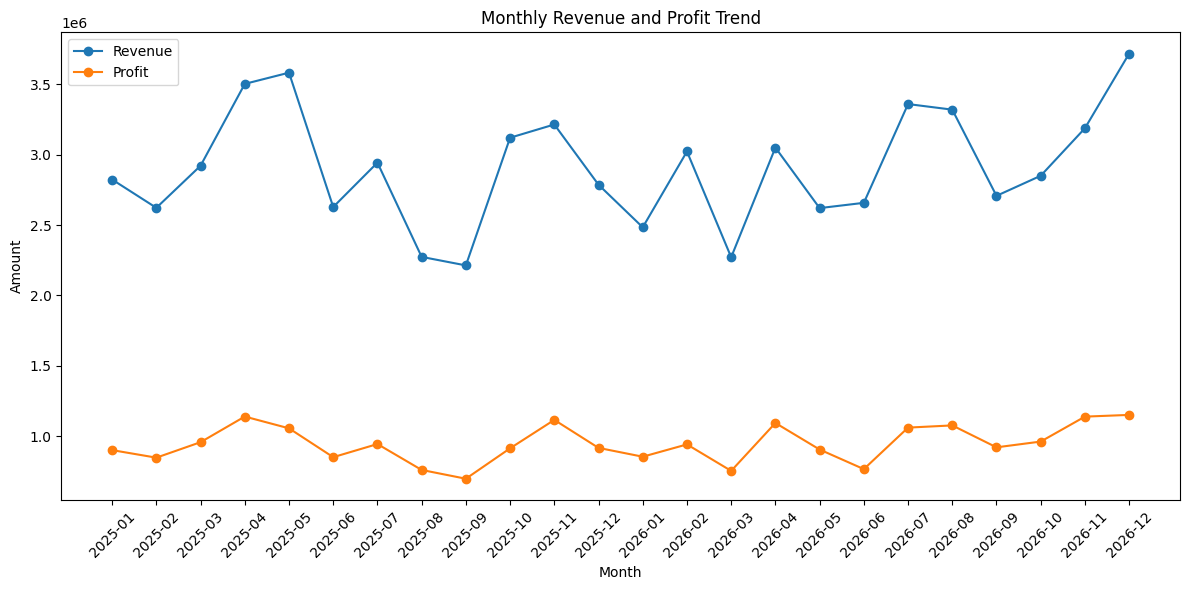

In [20]:
monthly_summary = (
    df.groupby("Year_Month")
      .agg(Revenue=("Revenue","sum"), Profit=("Profit","sum"))
      .sort_index()
)
display(monthly_summary)

plt.figure(figsize=(12,6))
plt.plot(monthly_summary.index, monthly_summary["Revenue"], marker="o", label="Revenue")
plt.plot(monthly_summary.index, monthly_summary["Profit"], marker="o", label="Profit")
plt.title("Monthly Revenue and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 17. Project Duration Analysis

,Project Duration (Days)
count,"1,483.00"
mean,37.80
std,17.64
min,5.00
25%,25.00
50%,38.00
75%,50.00
max,91.00


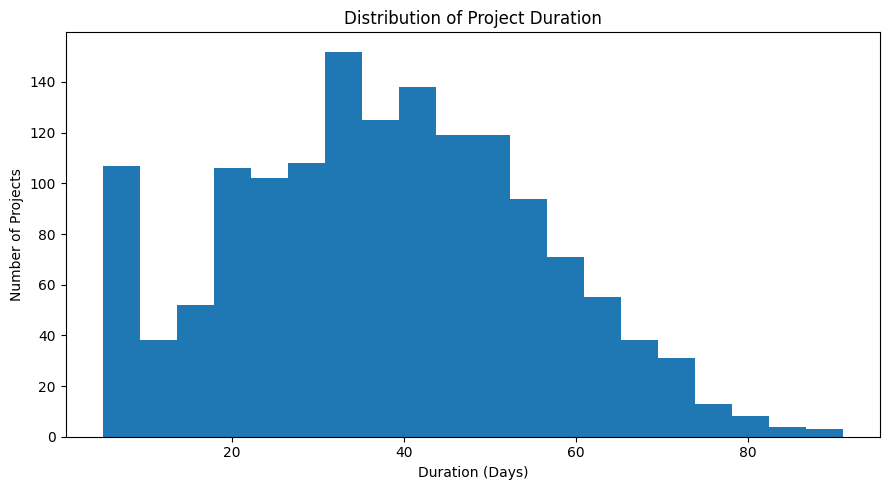

In [21]:
display(df["Project_Duration_Days"].describe().to_frame("Project Duration (Days)"))

plt.figure(figsize=(9,5))
plt.hist(df["Project_Duration_Days"].dropna(), bins=20)
plt.title("Distribution of Project Duration")
plt.xlabel("Duration (Days)")
plt.ylabel("Number of Projects")
plt.tight_layout()
plt.show()

## 18. Team Size Analysis

,Team Size
count,"1,501.00"
mean,5.86
std,2.56
min,2.00
25%,4.00
50%,6.00
75%,8.00
max,10.00


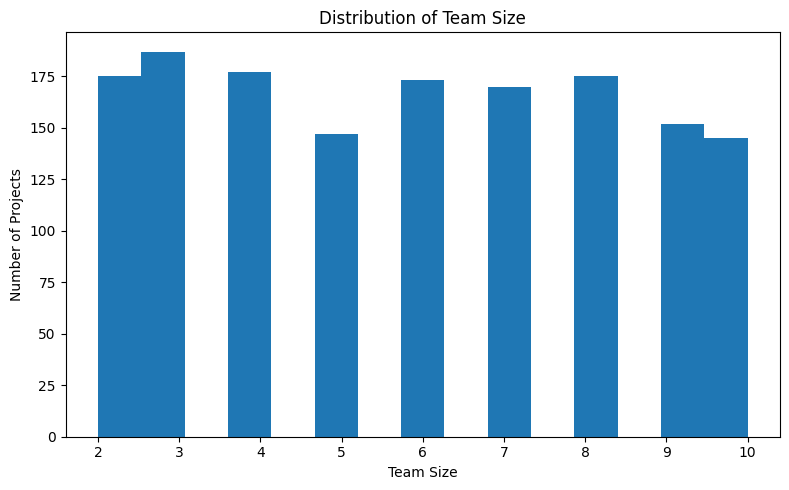

In [22]:
display(df["Team_Size"].describe().to_frame("Team Size"))

plt.figure(figsize=(8,5))
plt.hist(df["Team_Size"].dropna(), bins=15)
plt.title("Distribution of Team Size")
plt.xlabel("Team Size")
plt.ylabel("Number of Projects")
plt.tight_layout()
plt.show()

## 19. Customer Rating Analysis

,Projects
Customer_Rating,
2.00,1
2.20,2
2.30,3
2.40,2
2.50,8
2.60,6
2.70,7
2.80,21
2.90,21


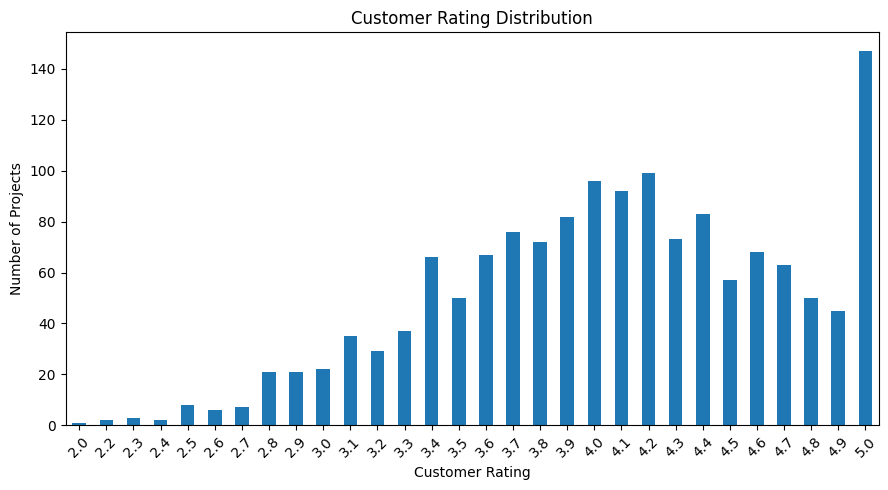

In [23]:
rating_counts = df["Customer_Rating"].round(1).value_counts().sort_index()
display(rating_counts.to_frame("Projects"))

plt.figure(figsize=(9,5))
rating_counts.plot(kind="bar")
plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Projects")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 20. Marketing Spend Analysis

,count,mean,std,min,25%,50%,75%,max
Marketing_Spend,"1,501.00","5,103.46","3,631.70","1,000.00","2,500.00","4,200.00","6,700.00","25,400.00"
Revenue,"1,501.00","46,553.83","26,888.46","12,000.00","27,100.00","39,700.00","60,000.00","203,200.00"
Profit,"1,501.00","15,146.10","11,816.96",-800.00,"7,000.00","11,700.00","19,900.00","82,700.00"


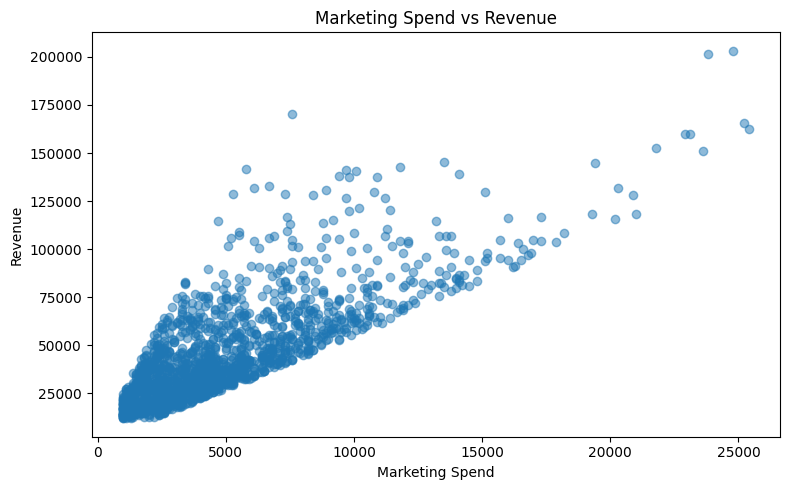

In [24]:
display(df[["Marketing_Spend","Revenue","Profit"]].describe().T)

plt.figure(figsize=(8,5))
plt.scatter(df["Marketing_Spend"], df["Revenue"], alpha=0.5)
plt.title("Marketing Spend vs Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

## 21. Profit Margin Analysis

,Profit Margin (%)
count,"1,501.00"
mean,31.84
std,13.85
min,-2.61
25%,21.59
50%,31.97
75%,42.73
max,58.16


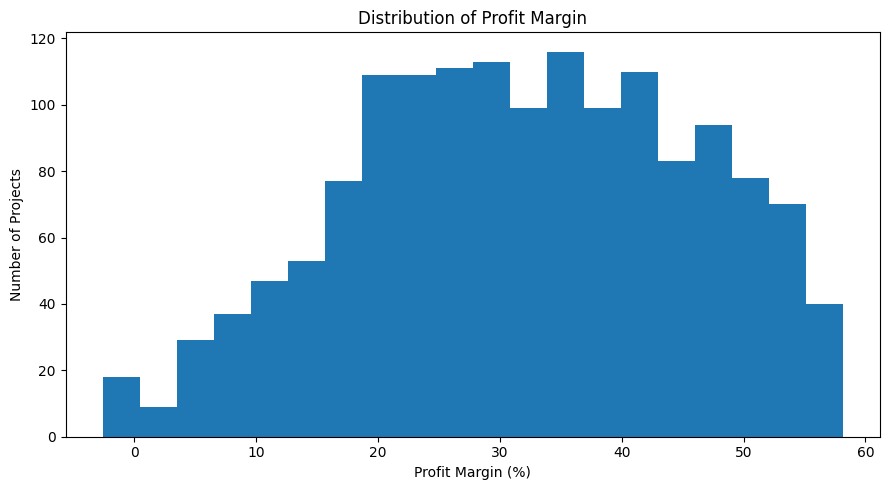

In [25]:
display(df["Profit_Margin_Pct"].describe().to_frame("Profit Margin (%)"))

plt.figure(figsize=(9,5))
plt.hist(df["Profit_Margin_Pct"].dropna(), bins=20)
plt.title("Distribution of Profit Margin")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Number of Projects")
plt.tight_layout()
plt.show()

## 22. Correlation Analysis

In [26]:
numeric_cols = [
    "Team_Size","Project_Duration_Days","Quoted_Value","Discount",
    "Revenue","Project_Cost","Profit","Profit_Margin_Pct",
    "Marketing_Spend","Customer_Rating"
]

correlation_matrix = df[numeric_cols].corr()
display(correlation_matrix.round(2))

,Team_Size,Project_Duration_Days,Quoted_Value,Discount,Revenue,Project_Cost,Profit,Profit_Margin_Pct,Marketing_Spend,Customer_Rating
Team_Size,1.00,-0.01,0.04,0.02,0.04,0.04,0.03,0.02,0.07,-0.01
Project_Duration_Days,-0.01,1.00,-0.04,0.01,-0.05,-0.04,-0.04,0.01,-0.04,0.01
Quoted_Value,0.04,-0.04,1.00,0.48,0.99,0.94,0.74,0.03,0.78,0.03
Discount,0.02,0.01,0.48,1.00,0.33,0.45,0.04,-0.30,0.25,0.04
Revenue,0.04,-0.05,0.99,0.33,1.00,0.92,0.79,0.09,0.79,0.03
Project_Cost,0.04,-0.04,0.94,0.45,0.92,1.00,0.50,-0.25,0.72,0.02
Profit,0.03,-0.04,0.74,0.04,0.79,0.50,1.00,0.60,0.65,0.03
Profit_Margin_Pct,0.02,0.01,0.03,-0.30,0.09,-0.25,0.60,1.00,0.09,-0.01
Marketing_Spend,0.07,-0.04,0.78,0.25,0.79,0.72,0.65,0.09,1.00,-0.00
Customer_Rating,-0.01,0.01,0.03,0.04,0.03,0.02,0.03,-0.01,-0.00,1.00


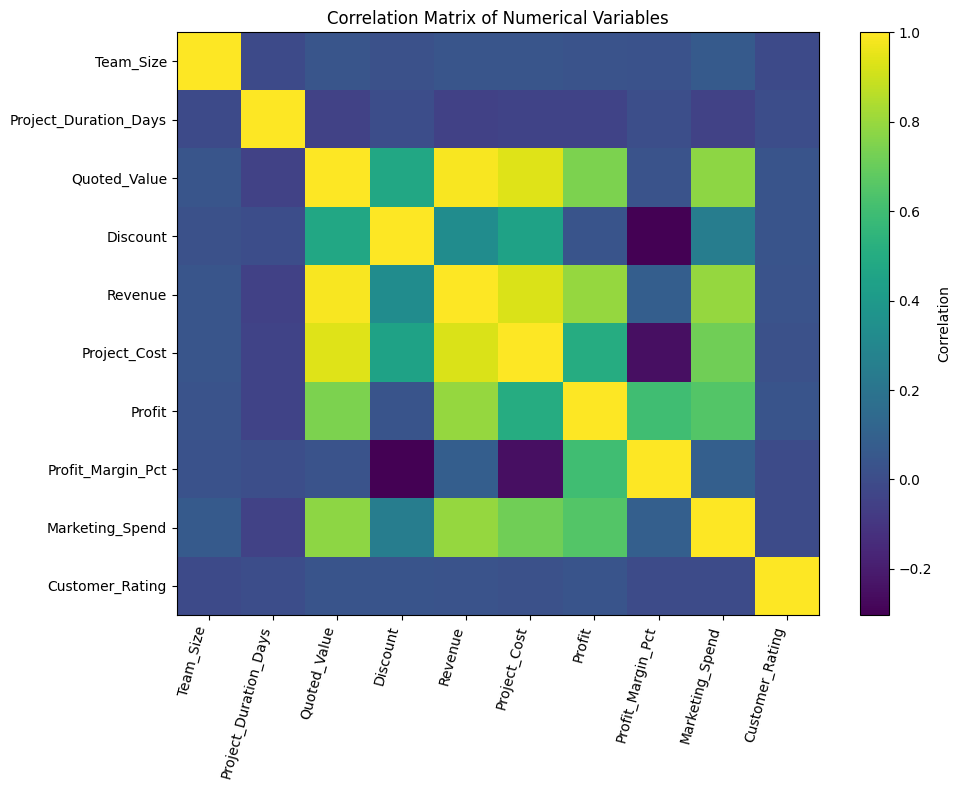

In [27]:
plt.figure(figsize=(10,8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=75, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

## 23. Top and Bottom Performing Services

In [28]:
print("Top 5 services by total profit:")
display(service_summary.sort_values("Profit", ascending=False).head(5))

print("Bottom 5 services by total profit:")
display(service_summary.sort_values("Profit", ascending=True).head(5))

print("Top 5 services by average profit margin:")
display(service_summary.sort_values("Avg_Margin", ascending=False).head(5))

Top 5 services by total profit:


,Projects,Revenue,Cost,Profit,Avg_Margin
Service,,,,,
Web Development,202,9287200,6253700,3033500,32.25
Mobile App Development,209,9331700,6399700,2932000,30.22
Online Reputation Management,184,8592300,5682200,2910100,33.07
Web Design,174,8576500,5677800,2898700,32.97
PPC,188,8826000,5995800,2830200,31.17


Bottom 5 services by total profit:


,Projects,Revenue,Cost,Profit,Avg_Margin
Service,,,,,
Content Marketing,186,8179100,5539300,2639800,31.60
Social Media Marketing,188,8645500,5910100,2735400,31.68
SEO,170,8439000,5684400,2754600,32.06
PPC,188,8826000,5995800,2830200,31.17
Web Design,174,8576500,5677800,2898700,32.97


Top 5 services by average profit margin:


,Projects,Revenue,Cost,Profit,Avg_Margin
Service,,,,,
Online Reputation Management,184,8592300,5682200,2910100,33.07
Web Design,174,8576500,5677800,2898700,32.97
Web Development,202,9287200,6253700,3033500,32.25
SEO,170,8439000,5684400,2754600,32.06
Social Media Marketing,188,8645500,5910100,2735400,31.68


## 24. Revenue and Profit by Project Status

In [29]:
status_financial = (
    df.groupby("Project_Status")
      .agg(Projects=("Project_ID","count"),
           Revenue=("Revenue","sum"),
           Cost=("Project_Cost","sum"),
           Profit=("Profit","sum"),
           Avg_Margin=("Profit_Margin_Pct","mean"))
      .sort_values("Revenue", ascending=False)
)
display(status_financial)

,Projects,Revenue,Cost,Profit,Avg_Margin
Project_Status,,,,,
Completed,939,43842800,29394200,14448600,32.29
Ongoing,321,14941800,10166500,4775300,31.24
Delayed,166,7686900,5296300,2390600,30.59
Cancelled,75,3405800,2286000,1119800,31.63


## 25. Data-backed Business Insights

In [30]:
top_service = service_summary["Revenue"].idxmax()
top_profit_service = service_summary["Profit"].idxmax()
top_region = region_summary["Revenue"].idxmax()
top_industry = industry_summary["Revenue"].idxmax()
top_lead = lead_summary["Revenue"].idxmax()
largest_client_type = client_summary["Projects"].idxmax()
completed_projects = int(status_counts.get("Completed", 0))

print(f"1. The dataset contains {len(df):,} project records across {df['Service'].nunique()} services.")
print(f"2. Total revenue is ₹{total_revenue:,.0f}, with total project cost of ₹{total_cost:,.0f}.")
print(f"3. Total profit is ₹{total_profit:,.0f}, with average project profit margin of {avg_margin:.2f}%.")
print(f"4. {top_service} generated the highest total revenue.")
print(f"5. {top_profit_service} generated the highest total profit.")
print(f"6. {top_region} generated the highest regional revenue.")
print(f"7. {top_industry} generated the highest industry revenue.")
print(f"8. {top_lead} generated the highest revenue among lead sources.")
print(f"9. {largest_client_type} is the largest client type by project count.")
print(f"10. {completed_projects:,} projects are marked as Completed.")
print(f"11. Average customer rating is {avg_rating:.2f} out of 5.")
print("12. Correlation analysis shows relationships among financial, operational, marketing and customer variables.")

1. The dataset contains 1,501 project records across 8 services.
2. Total revenue is ₹69,877,300, with total project cost of ₹47,143,000.
3. Total profit is ₹22,734,300, with average project profit margin of 31.84%.
4. Mobile App Development generated the highest total revenue.
5. Web Development generated the highest total profit.
6. Bengaluru generated the highest regional revenue.
7. Education generated the highest industry revenue.
8. Direct generated the highest revenue among lead sources.
9. New is the largest client type by project count.
10. 939 projects are marked as Completed.
11. Average customer rating is 4.06 out of 5.
12. Correlation analysis shows relationships among financial, operational, marketing and customer variables.
